In [1]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from speechbrain.inference import EncoderClassifier

D:\Projects\UrbanNoiseClassifier\project\audio-classifier\speechbrain-classifier\speechbrain\speechbrain\utils\torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [2]:
# --- 3. Config ---
AUDIO_DIR = "D:/Projects/UrbanNoiseClassifier/project/audio-classifier/data/raw/UrbanNoiseUganda61K/filtered_large_audio"   # path to folder with .wav files
CSV_PATH = "D:/Projects/UrbanNoiseClassifier/project/audio-classifier/data/raw/UrbanNoiseUganda61K/filtered_large_audio/filtered_labels.csv"
SAMPLE_RATE = 16000
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-4
MAX_LENGTH = 160000  # 10 seconds at 16kHz (adjust as needed)


In [3]:

# --- 4. Load CSV ---
df = pd.read_csv(CSV_PATH)
print(df.head())
num_classes = df["class_id"].nunique()


         filename        class  class_id
0   train_1_7.wav  crowd-noise         7
1   train_6_7.wav  crowd-noise         7
2   train_9_7.wav  crowd-noise         7
3  train_14_6.wav    generator         6
4  train_18_7.wav  crowd-noise         7


In [4]:

# --- 5. Train/Validation Split ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["class_id"], random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["class_id"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(valid_df)} | Test: {len(test_df)}")


Train: 13327 | Val: 2856 | Test: 2856


In [5]:
# --- 6. Dataset Class ---
class AudioCSVDataset(Dataset):
    def __init__(self, dataframe, audio_dir, max_length=MAX_LENGTH, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.max_length = max_length
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        filepath = os.path.join(self.audio_dir, row["filename"])
        label = int(row["class_id"])

        waveform, sr = torchaudio.load(filepath)

        # Convert stereo → mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample to 16 kHz
        if sr != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)

        # Pad or truncate to fixed length
        if waveform.shape[1] > self.max_length:
            # Truncate
            waveform = waveform[:, :self.max_length]
        elif waveform.shape[1] < self.max_length:
            # Pad with zeros
            padding = self.max_length - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        if self.transform:
            waveform = self.transform(waveform)

        # Return as 1D tensor [time] - SpeechBrain will handle the batching
        return waveform.squeeze(0), label


In [6]:
# --- 7. Create Datasets and Dataloaders ---
train_ds = AudioCSVDataset(train_df, AUDIO_DIR)
valid_ds = AudioCSVDataset(valid_df, AUDIO_DIR)
test_ds  = AudioCSVDataset(test_df, AUDIO_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)


### Alternative: Use Dynamic Batching (Better Semantics)
If you want to avoid truncation/padding semantics issues, you can use a custom collate function that pads to the longest sample in each batch (not globally). This preserves more information but adds complexity.

In [7]:
# Custom collate function for dynamic padding (optional - better semantics)
def collate_fn_dynamic_pad(batch):
    """Pad to longest sample in batch instead of fixed MAX_LENGTH"""
    waveforms, labels = zip(*batch)
    
    # Find max length in this batch
    max_len = max(w.shape[0] for w in waveforms)
    
    # Pad each waveform to max_len
    padded_waveforms = []
    for w in waveforms:
        if w.shape[0] < max_len:
            padding = max_len - w.shape[0]
            w = torch.nn.functional.pad(w, (0, padding))
        padded_waveforms.append(w)
    
    return torch.stack(padded_waveforms), torch.tensor(labels)

# Uncomment below to use dynamic padding instead of fixed MAX_LENGTH:
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_dynamic_pad)
# valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn_dynamic_pad)
# test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn_dynamic_pad)

In [8]:
# --- 8. Load Pretrained Model ---
base_model = EncoderClassifier.from_hparams(
    source="speechbrain/urbansound8k_ecapa",
    savedir="pretrained_urbansound8k"
)


D:\Projects\UrbanNoiseClassifier\project\audio-classifier\speechbrain-classifier\speechbrain\speechbrain\utils\torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
D:\Projects\UrbanNoiseClassifier\project\audio-classifier\speechbrain-classifier\speechbrain\speechbrain\utils\autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
D:\Projects\UrbanNoiseClassifier\project\audio-class

In [9]:

print("Available modules:", base_model.mods.keys())

Available modules: dict_keys(['compute_features', 'mean_var_norm', 'embedding_model', 'classifier'])


In [10]:
# --- Freeze encoder (embedding model) ---
for param in base_model.mods.embedding_model.parameters():
    param.requires_grad = False

In [11]:
print(base_model.mods.classifier)


Classifier(
  (blocks): ModuleList()
)


In [12]:
# Replace classifier for your number of classes
# The classifier is a Classifier module, we need to get the input features from the embedding model
# The ECAPA-TDNN embedding model typically outputs 192-dimensional features
n_features = 192  # ECAPA-TDNN output dimension

# Create a new linear classifier
new_classifier = nn.Sequential(
    nn.Linear(n_features, num_classes)
)
base_model.mods.classifier = new_classifier


In [13]:
# --- 9. Training setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = base_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.mods.classifier.parameters(), lr=LR)

train_losses, val_accuracies = [], []

In [14]:
# --- Debug: Test with compute_features (the correct approach) ---
sample_waveforms, sample_labels = next(iter(train_loader))
sample_waveforms = sample_waveforms.to(device)
print(f"Sample batch shape: {sample_waveforms.shape}")

# The correct way: use compute_features from the model's mods
try:
    with torch.no_grad():
        # Check if there's a compute_features module
        if hasattr(model.mods, 'compute_features'):
            feats = model.mods.compute_features(sample_waveforms)
            print(f"✅ compute_features works: {sample_waveforms.shape} → {feats.shape}")
            embeddings = model.mods.embedding_model(feats)
            print(f"✅ Full pipeline works: waveform → features → embeddings {embeddings.shape}")
        else:
            print("❌ No compute_features module found")
            print(f"Available modules: {list(model.mods.keys())}")
except Exception as e:
    print(f"❌ Failed: {e}")
    import traceback
    traceback.print_exc()

d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Sample batch shape: torch.Size([8, 160000])
✅ compute_features works: torch.Size([8, 160000]) → torch.Size([8, 1001, 80])
✅ compute_features works: torch.Size([8, 160000]) → torch.Size([8, 1001, 80])
✅ Full pipeline works: waveform → features → embeddings torch.Size([8, 1, 192])
✅ Full pipeline works: waveform → features → embeddings torch.Size([8, 1, 192])


In [15]:
# --- 10. Training loop ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for waveforms, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        waveforms, labels = waveforms.to(device), labels.to(device)
        
        # Step 1: Extract features (waveform → mel-spectrogram)
        feats = model.mods.compute_features(waveforms)
        
        # Step 2: Get embeddings (features → embeddings)
        embeddings = model.mods.embedding_model(feats)
        
        # Step 3: Classify (embeddings → logits)
        logits = model.mods.classifier(embeddings.squeeze(1))
        
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for waveforms, labels in valid_loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            feats = model.mods.compute_features(waveforms)
            embeddings = model.mods.embedding_model(feats)
            logits = model.mods.classifier(embeddings.squeeze(1))
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/100: 100%|██████████| 1666/1666 [03:31<00:00,  7.89it/s]



Epoch 1/100 | Train Loss: 1.8059 | Val Acc: 0.4849


Epoch 2/100: 100%|██████████| 1666/1666 [03:28<00:00,  8.00it/s]



Epoch 2/100 | Train Loss: 1.5188 | Val Acc: 0.5466


Epoch 3/100: 100%|██████████| 1666/1666 [03:27<00:00,  8.05it/s]



...

Epoch 98/100 | Train Loss: 0.9880 | Val Acc: 0.6978


Epoch 99/100: 100%|██████████| 1666/1666 [03:34<00:00,  7.76it/s]



Epoch 99/100 | Train Loss: 0.9891 | Val Acc: 0.6975


Epoch 100/100: 100%|██████████| 1666/1666 [03:37<00:00,  7.67it/s]



Epoch 100/100 | Train Loss: 0.9833 | Val Acc: 0.6954


In [16]:
# --- 11. Save fine-tuned model ---
torch.save(model.state_dict(), "fine_tuned_urbansound8k_8class.pth")
print("✅ Fine-tuned model saved successfully.")


✅ Fine-tuned model saved successfully.


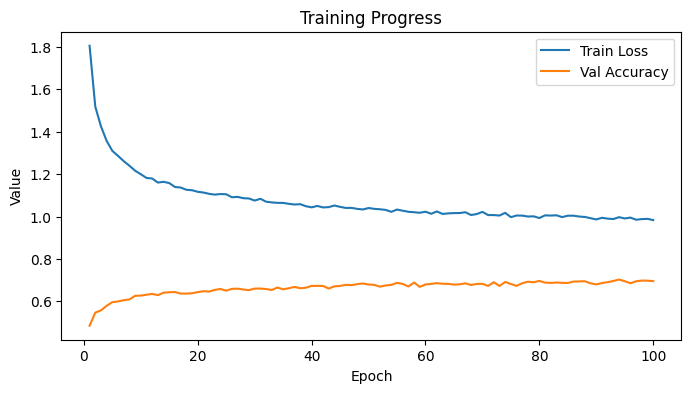

In [17]:
# --- 12. Plot Training Progress ---
plt.figure(figsize=(8,4))
plt.plot(range(1,EPOCHS+1), train_losses, label="Train Loss")
plt.plot(range(1,EPOCHS+1), val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.title("Training Progress")
plt.show()


In [18]:
# --- 13. Final Evaluation on Test Set ---
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for waveforms, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        waveforms, labels = waveforms.to(device), labels.to(device)
        
        feats = model.mods.compute_features(waveforms)
        embeddings = model.mods.embedding_model(feats)
        logits = model.mods.classifier(embeddings.squeeze(1))
        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


Evaluating on Test Set: 100%|██████████| 357/357 [00:48<00:00,  7.38it/s]


In [19]:
# --- 14. Classification Metrics ---
print("\n📊 Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=df["class"].unique()))



📊 Classification Report (Test Set):
                    precision    recall  f1-score   support

       crowd-noise       0.62      0.72      0.67       407
         generator       0.82      0.86      0.84       184
 motorvehicle-horn       0.90      0.72      0.80       314
      mobile-music       0.68      0.61      0.64       380
   community-radio       0.77      0.53      0.63       366
 construction-site       0.63      0.60      0.61       330
motorvehicle-siren       0.65      0.82      0.72       294
         car-alarm       0.66      0.76      0.71       581

          accuracy                           0.69      2856
         macro avg       0.72      0.70      0.70      2856
      weighted avg       0.70      0.69      0.69      2856



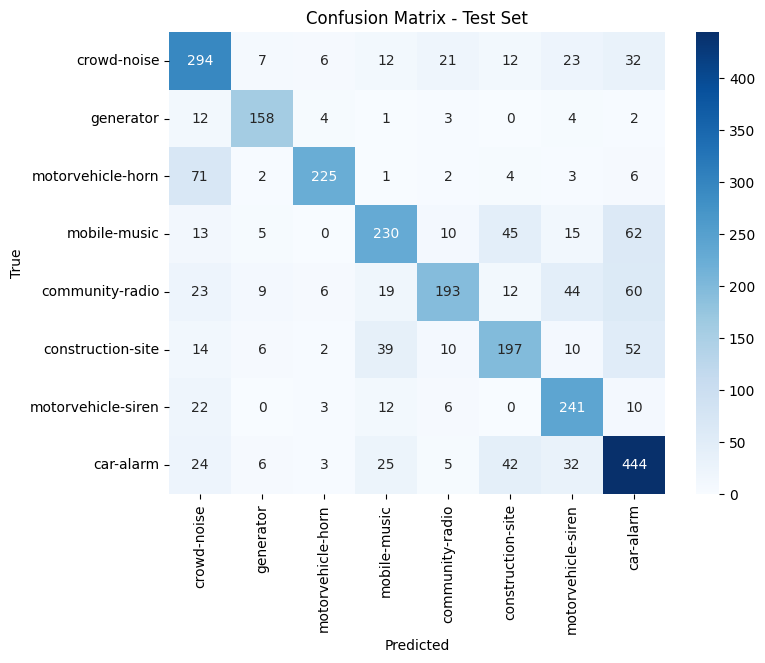

In [20]:
# --- 15. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
labels_sorted = df["class"].unique()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_sorted, yticklabels=labels_sorted, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()
